# Configures and Runs MCXCL

In [2]:
# Imports
import math
import numpy as np
import scipy as sp
import pmcxcl
import matplotlib.pyplot as plt
import copy

# Input Allocation

In [3]:
# Path Variables:
repo_path = "/Users/caoze/Documents/GitHub/Photon-Transport-Simulation/"     # Replace with repository path
export_address = "output/mcxcl/"
access_address = "data/media_label/"

# Helpers:
def output_address(subfolder="data/", repository=repo_path):
    out_path = f"{repository}{subfolder}"
    return out_path

def modified_output_address(filename, tag = "flux"):
    name_part = filename.split("_")[0]
    new_name = f"{name_part}_{tag}.npy"         # Tag File Type
    return new_name

In [4]:
# Accessing
filename = "lifted_parasite_label.mat"
access_path = f"{repo_path}{access_address}{filename}"
print("Accessing: " + access_path)
content = sp.io.loadmat(access_path)
print(content.keys())

Accessing: /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/data/media_label/lifted_parasite_label.mat
dict_keys(['__header__', '__version__', '__globals__', 'ri_label'])


# Extraction and Labeling

(150, 150)


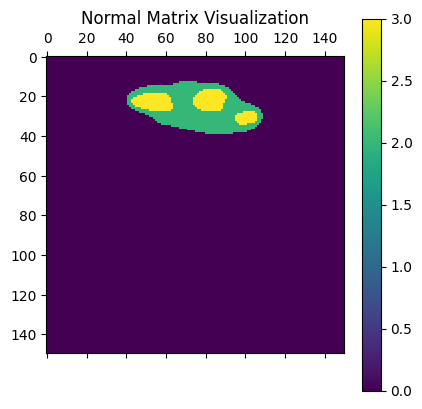

In [5]:
# Retrieve Matrix
extract = content['ri_label']
pix_num = [extract.shape[1], extract.shape[0]]
print(extract.shape)

# Verify
plt.matshow(extract) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Normal Matrix Visualization")
plt.show() 

Gel cutoff at 39
Values:  [0. 1. 2. 3.]
Dimentsions:  (150, 150)


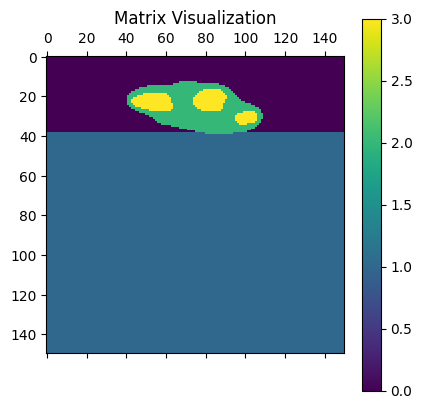

In [6]:
# RI Matrix labeling(0 = air, 1 = gel, 2 = body):
# Padding Labels
air = 0
gel = 1

# Helper
def pad(arr, air, gel, cutoff, depth):

    # Above cutoff
    rows_air = arr[:cutoff, :]
    rows_air[rows_air == 0] = air
    arr[:cutoff, :] = rows_air

    # Below cutoff
    rows_gel = arr[cutoff:depth, :]
    rows_gel[rows_gel == 0] = gel
    arr[cutoff:depth, :] = rows_gel

    return arr
def find_cutoff(array):
    # Find the lowest point on z where the cell is still present, this is the gel line makesure there are consistently 3 consecutive points in the row.
    cell_level= []
    for i in range(array.shape[0]):
        if np.sum(array[i,:]) > 0: # If there are any non-zero values in the row, it means the cell is present
            if i > 1 and np.sum(array[i-1,:]) > 0 and np.sum(array[i-2,:]) > 0: # Check for 3 consecutive rows
                cell_level.append(i)
    return max(cell_level) # The lowest point where the cell is still present

# Padding
cutoff = find_cutoff(extract)
print(f"Gel cutoff at {cutoff}")

padded= pad(extract, air, gel, cutoff, pix_num[1])
print("Values: ", np.unique(padded))
print("Dimentsions: ", padded.shape)

# Visualized
plt.matshow(extract) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Matrix Visualization")
plt.show() 

# Sample Simulation and Configurations

In [7]:
# Build Volume
# padded = padded.astype(np.uint8)  # For testing
padded = padded.astype(np.uint8)

pad = 100
vol = np.repeat(padded[:,:, None], pad, axis = 2)

print("Volume saved:", vol.shape)
print("Volume with parasite saved:", vol.shape)
print("Tissue labels:", np.unique(vol))
print("Tissue labels with paracyte:", np.unique(vol))

Volume saved: (150, 150, 100)
Volume with parasite saved: (150, 150, 100)
Tissue labels: [0 1 2 3]
Tissue labels with paracyte: [0 1 2 3]


In [14]:
# 45 degree across sample:
def corner_to_corner(length, height):
    mag = math.sqrt(length**2 + height**2 + 1)
    return [length/mag, height/mag, 1/mag]

# PMCXCL Configurations
cfg = {
    'nphoton': 5000000,         # of photons
    'vol':vol, 

    'unitinmm' : 1e-3,

    'tstart':0, 
    'tend':1e-11, 
    'tstep':5e-13,

    'srcpos': [0,0,pad/2],                      # Source Position
    'srcdir':corner_to_corner(pix_num[1], pix_num[0]),             # Source Direction
    'srctype': "pencil",

    'bc' : "r",         # Boundary Condition/Behavior - r = reflect, a = absorb, p = periodic

    'prop':[[0, 0, 1.0, 1.0],           # Air
            [0.005, 0.5, 0.9, 1.357],   # Gel   
            [0.2, 25, 0.98, 1.40],      # RBC
            [0.3, 20.0, 0.85, 1.37]     # parasite
            ]
}


cfg_sub = copy.deepcopy(cfg)  # Same as parasite, but assume parasite medium is a part of the cell medium
cfg["prop"] = [[0, 0, 1.0, 1.0],           # Air
            [0.005, 0.5, 0.9, 1.357],   # Gel   
            [0.2, 25, 0.98, 1.40],      # RBC
            [0.2, 25, 0.98, 1.40]     # parasite sub a RBC
            ]           

In [15]:
# Run the simulation
print("Running MCXCL simulation...")
res = pmcxcl.run(cfg)
print("Complete!!!")
print(res.keys())

# Pull out info
flux = res["flux"]
print(flux.shape)


Running MCXCL simulation...
nphoton: 5e+06
tstart: 0
tstep: 5e-13
tend: 1e-11
unitinmm: 0.001
Complete!!!
dict_keys(['flux', 'stat'])
(150, 150, 100, 20)


In [16]:
# Rerun with parasite substituted configuration
print("Running MCXCL simulation with substituted parasite...")
res_sub = pmcxcl.run(cfg_sub)
print("Complete!!!")
print(res_sub.keys())

flux_sub = res_sub["flux"]
print(flux_sub.shape)

Running MCXCL simulation with substituted parasite...
nphoton: 5e+06
tstart: 0
tstep: 5e-13
tend: 1e-11
unitinmm: 0.001
Complete!!!
dict_keys(['flux', 'stat'])
(150, 150, 100, 20)


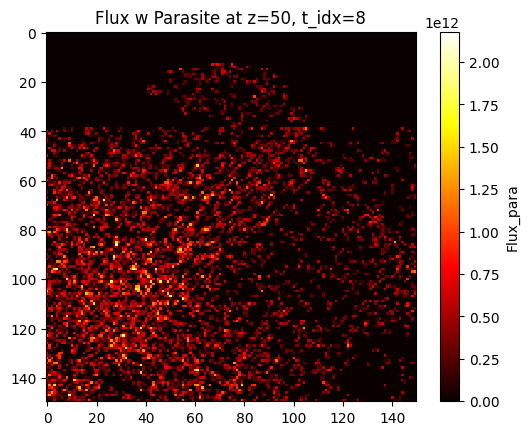

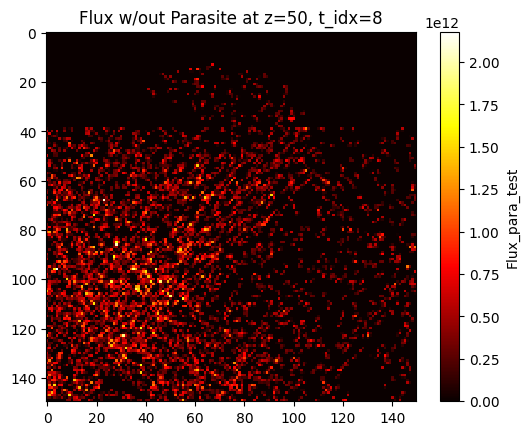

In [18]:
# Visualize
# Pick time index, e.g., 0
t_idx = 8

# Pick a mid-plane slice
mid_pad = int(pad/2)

# Slice: select a single time
slice_z = flux[:, :, int(mid_pad), t_idx]
sub_slice_z = flux_sub[:, :, int(mid_pad), t_idx]

# Display
plt.imshow(slice_z, cmap='hot', interpolation='nearest')
plt.colorbar(label="Flux_para")
plt.title(f"Flux w Parasite at z={mid_pad}, t_idx={t_idx}")
plt.show()

plt.imshow(sub_slice_z, cmap='hot', interpolation='nearest')
plt.colorbar(label="Flux_para_test")
plt.title(f"Flux w/out Parasite at z={mid_pad}, t_idx={t_idx}")
plt.show()

In [12]:
# Save Test Output
output_path = output_address(export_address, repo_path)
output_name = modified_output_address(filename)

# Saving
np.save(f"{output_path}{output_name}",flux)
print(f"Successfully saved to: {output_path}{output_name}")

Successfully saved to: /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/output/mcxcl/lifted_flux.npy


In [13]:
# Saving Output
output_path = output_address(export_address, repo_path)
output_name_para = modified_output_address(filename, tag="para_flux")
output_name_para = modified_output_address(filename, tag="para_sub_flux")

# Saving
np.save(f"{output_path}{output_name_para}", flux)
print(f"Successfully saved to: {output_path}{output_name_para}")

np.save(f"{output_path}{output_name_para}", flux_sub)
print(f"successfully saved to: {output_path}{output_name_para}")

Successfully saved to: /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/output/mcxcl/lifted_para_sub_flux.npy
successfully saved to: /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/output/mcxcl/lifted_para_sub_flux.npy
